# Illustrative CEV/IAV Examples
**Focused notebook for exact activation-pattern extraction**

This notebook trains the lightweight CEV/IAV probes and extracts exact numerical activation patterns from the ablation-selected single middle decoder layer:

\[
\ell^{*}=\left\lfloor\frac{L}{2}\right\rfloor.
\]

For the 32-layer Mistral-7B-Instruct-v0.2 backbone, this corresponds to decoder layer 16.


---
## 1. Environment Setup

In [1]:
# Install only packages that are actually missing.
# Do not upgrade Kaggle's full scientific stack, because broad pip upgrades can
# replace numba/cuda-core versions required by RAPIDS.

import importlib.util
import os
import subprocess
import sys
import warnings

warnings.filterwarnings("ignore")

required_packages = {
    "transformers": "transformers>=4.40,<5",
    "accelerate": "accelerate>=0.29,<2",
    "bitsandbytes": "bitsandbytes>=0.45,<1",
    "huggingface_hub": "huggingface_hub>=0.23,<1",
    "datasets": "datasets>=2.18,<4",
    "sentence_transformers": "sentence-transformers>=2.6,<4",
    "sklearn": "scikit-learn>=1.3,<2",
}

missing_specs = [
    spec
    for module_name, spec in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_specs:
    print("Installing missing packages only:", missing_specs)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "--no-deps", *missing_specs]
    )
else:
    print("All required packages are already available; pip installation skipped.")

# Kaggle temporary caches
os.environ["HF_HOME"] = "/tmp/hf_cache"
os.environ["TRANSFORMERS_CACHE"] = "/tmp/hf_cache"
os.environ["HF_DATASETS_CACHE"] = "/tmp/datasets_cache"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

os.makedirs("/tmp/hf_cache", exist_ok=True)
os.makedirs("/tmp/datasets_cache", exist_ok=True)

print("\nPackage check:")
for module_name in required_packages:
    status = "OK" if importlib.util.find_spec(module_name) is not None else "MISSING"
    print(f"  {module_name}: {status}")

print("\nRequired Kaggle setting: Internet = ON")
print("Optional Kaggle secret: HF_TOKEN")


Installing missing packages only: ['bitsandbytes>=0.45,<1']
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.7 MB/s eta 0:00:00

Package check:
  transformers: OK
  accelerate: OK
  bitsandbytes: OK
  huggingface_hub: OK
  datasets: OK
  sentence_transformers: OK
  sklearn: OK

Required Kaggle setting: Internet = ON
Optional Kaggle secret: HF_TOKEN


---
## 2. Imports and Runtime Check

In [2]:
import gc
import json
import math
import os
import random
import time
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU count: {torch.cuda.device_count()}")
for index in range(torch.cuda.device_count()):
    name = torch.cuda.get_device_name(index)
    memory = torch.cuda.get_device_properties(index).total_memory / 1e9
    print(f"  GPU {index}: {name} ({memory:.2f} GB)")


PyTorch version: 2.10.0+cu128
CUDA available: True
GPU count: 2
  GPU 0: Tesla T4 (15.64 GB)
  GPU 1: Tesla T4 (15.64 GB)


---
## 3. Focused Configuration


The final architecture uses only the ablation-selected **single middle layer**.


In [3]:
@dataclass
class Config:
    # Exact Hugging Face model used by the main Mistral experiment.
    model_name: str = "mistralai/Mistral-7B-Instruct-v0.2"

    # Quantization / memory.
    use_8bit: bool = True
    use_4bit: bool = False

    # The ablation-selected representation: one middle decoder layer only.
    target_layers: Optional[List[int]] = None
    probe_concat_n_layers: int = 1
    hidden_size: int = 4096
    intermediate_size: int = 14336
    max_context_length: int = 2048

    # Reduced Kaggle training budget retained to avoid OOM.
    probe_train_samples: int = 1500
    synthetic_squad_rows: int = 200
    probe_val_fraction: float = 0.20
    probe_hidden_size: int = 256
    probe_lr: float = 3e-4
    probe_epochs: int = 40
    probe_batch_size: int = 32
    probe_early_stop_patience: int = 10

    # Calibration and deployment-style interpretation.
    probe_fusion_weight: float = 0.5
    probe_temp_cev: float = 1.0
    probe_temp_iav: float = 1.0
    probe_fused_val_auroc: float = 0.0
    hallucination_threshold: float = 0.67
    abstain_threshold: float = 0.80
    retrieval_quality_threshold: float = 0.30

    # Example output.
    top_k_dimensions: int = 12
    embedding_model: str = "BAAI/bge-base-en-v1.5"
    random_seed: int = 42
    output_dir: str = "/kaggle/working/illustrative_cev_iav_examples"
    checkpoint_dir: str = "/kaggle/working/illustrative_cev_iav_examples/checkpoints"


config = Config()

random.seed(config.random_seed)
np.random.seed(config.random_seed)
torch.manual_seed(config.random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.random_seed)

os.makedirs(config.output_dir, exist_ok=True)
os.makedirs(config.checkpoint_dir, exist_ok=True)

print("Focused configuration")
print(f"  Hugging Face model: {config.model_name}")
print(f"  RAGTruth training cap: {config.probe_train_samples}")
print(f"  Single-layer probe: {config.probe_concat_n_layers == 1}")
print(f"  Output directory: {config.output_dir}")


Focused configuration
  Hugging Face model: mistralai/Mistral-7B-Instruct-v0.2
  RAGTruth training cap: 1500
  Single-layer probe: True
  Output directory: /kaggle/working/illustrative_cev_iav_examples


---
## 4. Load Only the Required Datasets

In [4]:
class DatasetLoader:
    @staticmethod
    def load_squad():
        print("Loading SQuAD...")
        dataset = load_dataset("rajpurkar/squad")
        print(f"  train={len(dataset['train'])}, validation={len(dataset['validation'])}")
        return dataset

    @staticmethod
    def load_ragtruth():
        print("Loading RAGTruth...")
        candidates = [
            "wandb/RAGTruth-processed",
            "leobianco/ragtruth_sft",
            "jakobsnel/RAGTruth_Xtended",
        ]
        last_error = None
        for repository in candidates:
            try:
                dataset = load_dataset(repository)
                print(f"  loaded from {repository}")
                for split in ("train", "validation", "test"):
                    if split in dataset:
                        print(f"  {split}={len(dataset[split])}")
                return dataset
            except Exception as error:
                last_error = error
                print(f"  skipped {repository}: {error}")
        raise RuntimeError("No RAGTruth source could be loaded.") from last_error


try:
    squad_data = DatasetLoader.load_squad()
except Exception as error:
    print(f"SQuAD unavailable: {error}")
    squad_data = None

try:
    ragtruth_data = DatasetLoader.load_ragtruth()
except Exception as error:
    print(f"RAGTruth unavailable: {error}")
    ragtruth_data = None

if ragtruth_data is None:
    raise RuntimeError(
        "RAGTruth is required for this notebook. "
        "Check internet access or attach a compatible local copy."
    )


Loading SQuAD...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

...

data/train-00000-of-00001.parquet:   0%|          | 0.00/22.3M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/3.88M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15090 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2700 [00:00<?, ? examples/s]

  loaded from wandb/RAGTruth-processed
  train=15090
  test=2700


---
## 5. Load Mistral-7B-Instruct-v0.2 from Hugging Face and Fix the Middle Layer

The notebook uses `AutoTokenizer` and `AutoModelForCausalLM` because the
activation hooks must access the Hugging Face decoder modules directly.
The separate `mistral_common` and `mistral_inference` path is therefore not
used in this notebook.


In [5]:
import gc

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")


def get_llm_device(m) -> torch.device:
    """Return a suitable device for inputs when the model uses device_map."""
    try:
        return m.device
    except Exception:
        return next(m.parameters()).device


def resolve_hf_token() -> Optional[str]:
    """
    Resolve an optional Hugging Face token.

    Mistral-7B-Instruct-v0.2 is loaded from the Hugging Face Hub. A token is
    usually not required for this public checkpoint, but this helper supports
    either an environment variable or a Kaggle secret named HF_TOKEN.
    """
    token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_TOKEN")

    if token:
        return token.strip()

    try:
        from kaggle_secrets import UserSecretsClient

        token = UserSecretsClient().get_secret("HF_TOKEN")
        return token.strip() if token else None
    except Exception:
        return None


def load_model_and_tokenizer(config: Config):
    """Load Mistral-7B-Instruct-v0.2 from Hugging Face with OOM-safe quantization."""
    expected_model = "mistralai/Mistral-7B-Instruct-v0.2"
    if config.model_name != expected_model:
        raise ValueError(
            f"This focused notebook must use '{expected_model}', "
            f"but received '{config.model_name}'."
        )

    print(f"Loading Hugging Face model: {config.model_name}")
    hf_token = resolve_hf_token()
    print(f"  Hugging Face token detected: {hf_token is not None}")

    if config.use_8bit:
        quantization_config = BitsAndBytesConfig(
            load_in_8bit=True,
            llm_int8_threshold=6.0,
        )
        print("  Requested precision: 8-bit")
    elif config.use_4bit:
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
        )
        print("  Requested precision: 4-bit NF4")
    else:
        quantization_config = None
        print("  Requested precision: FP16")

    tokenizer = AutoTokenizer.from_pretrained(
        config.model_name,
        token=hf_token,
        padding_side="left",
        use_fast=True,
        trust_remote_code=False,
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.clean_up_tokenization_spaces = False

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if torch.cuda.is_available():
        max_memory = {}
        for gpu_index in range(torch.cuda.device_count()):
            total_gib = int(
                torch.cuda.get_device_properties(gpu_index).total_memory
                / (1024**3)
            )
            max_memory[gpu_index] = f"{max(total_gib - 2, 1)}GiB"
        max_memory["cpu"] = "16GiB"
    else:
        max_memory = None

    load_kwargs = {
        "device_map": "auto",
        "low_cpu_mem_usage": True,
        "token": hf_token,
        "trust_remote_code": False,
    }
    if max_memory is not None:
        load_kwargs["max_memory"] = max_memory

    try:
        model = AutoModelForCausalLM.from_pretrained(
            config.model_name,
            quantization_config=quantization_config,
            torch_dtype=torch.float16 if quantization_config is None else None,
            **load_kwargs,
        )
    except Exception as error:
        if config.use_8bit:
            print(
                "  8-bit loading failed; retrying with 4-bit NF4.\n"
                f"  Original error: {error}"
            )
            quantization_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.float16,
                bnb_4bit_use_double_quant=True,
            )
            model = AutoModelForCausalLM.from_pretrained(
                config.model_name,
                quantization_config=quantization_config,
                **load_kwargs,
            )
        else:
            raise RuntimeError(
                "Hugging Face model loading failed. Confirm that Kaggle "
                "Internet is enabled and that the runtime has sufficient RAM."
            ) from error

    model.eval()
    model.config.use_cache = False
    if getattr(model, "generation_config", None) is not None:
        model.generation_config.use_cache = False

    config.hidden_size = int(model.config.hidden_size)
    config.intermediate_size = int(model.config.intermediate_size)

    num_layers = len(model.model.layers)
    mid_layer = num_layers // 2
    config.target_layers = [mid_layer]
    config.probe_concat_n_layers = 1

    print("\nModel verification")
    print(
        "  Loaded checkpoint: "
        f"{getattr(model.config, '_name_or_path', config.model_name)}"
    )
    print(f"  Architecture: {model.__class__.__name__}")
    print(f"  Decoder layers: {num_layers}")
    print(f"  Selected middle layer: {config.target_layers}")
    print(f"  Hidden size: {config.hidden_size}")
    print(f"  Intermediate size: {config.intermediate_size}")
    print(f"  Device map: {getattr(model, 'hf_device_map', 'single device')}")

    for gpu_index in range(torch.cuda.device_count()):
        allocated = torch.cuda.memory_allocated(gpu_index) / 1e9
        reserved = torch.cuda.memory_reserved(gpu_index) / 1e9
        print(
            f"  GPU {gpu_index}: "
            f"{allocated:.2f} GB allocated, {reserved:.2f} GB reserved"
        )

    return model, tokenizer, mid_layer


model, tokenizer, mid_layer = load_model_and_tokenizer(config)

assert len(model.model.layers) == 32, (
    f"Expected 32 decoder layers, found {len(model.model.layers)}."
)
assert config.target_layers == [16], (
    f"Expected the selected middle layer to be [16], got {config.target_layers}."
)
assert config.hidden_size == 4096
assert config.intermediate_size == 14336

print("\nHugging Face checkpoint and middle-layer selection verified.")


Loading Hugging Face model: mistralai/Mistral-7B-Instruct-v0.2
  Hugging Face token detected: True
  Requested precision: 8-bit


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]


Model verification
  Loaded checkpoint: mistralai/Mistral-7B-Instruct-v0.2
  Architecture: MistralForCausalLM
  Decoder layers: 32
  Selected middle layer: [16]
  Hidden size: 4096
  Intermediate size: 14336
  Device map: {'model.embed_tokens': 0, 'model.layers.0': 0, 'model.layers.1': 0, 'model.layers.2': 0, 'model.layers.3': 0, 'model.layers.4': 0, 'model.layers.5': 0, 'model.layers.6': 0, 'model.layers.7': 0, 'model.layers.8': 0, 'model.layers.9': 0, 'model.layers.10': 0, 'model.layers.11': 0, 'model.layers.12': 0, 'model.layers.13': 0, 'model.layers.14': 1, 'model.layers.15': 1, 'model.layers.16': 1, 'model.layers.17': 1, 'model.layers.18': 1, 'model.layers.19': 1, 'model.layers.20': 1, 'model.layers.21': 1, 'model.layers.22': 1, 'model.layers.23': 1, 'model.layers.24': 1, 'model.layers.25': 1, 'model.layers.26': 1, 'model.layers.27': 1, 'model.layers.28': 1, 'model.layers.29': 1, 'model.layers.30': 1, 'model.layers.31': 1, 'model.norm': 1, 'model.rotary_emb': 1, 'lm_head': 1}
  G

---
## 6. OOM-Safe Single-Layer CEV/IAV Extraction

- **CEV:** selected decoder-block residual output.
- **IAV:** input to the MLP's final `down_proj`.
- **Pooling:** the last token is selected **inside the hook**.
- **Stored tensor per sample:** only `[1, 1, feature_dim]`, not the full sequence.
- **Depth:** one ablation-selected middle layer, \(\ell^*=16\).
- **KV cache:** disabled during feature extraction.
- **GPU behavior:** each pooled vector is detached and transferred immediately to CPU.

This preserves the exact last-token activation used by the probes while avoiding
the full-sequence activation copies that caused the previous Kaggle kernel death.


In [6]:
class HiddenStateExtractor:
    """
    Memory-safe CEV/IAV extraction for one selected decoder layer.

    CEV:
        Last-token residual-stream output of the selected decoder block.

    IAV:
        Last-token input to the selected block's MLP down_proj module.

    Important:
        Pooling is performed inside each hook before CPU transfer. The extractor
        never stores the complete [batch, sequence, feature] activation tensor.
    """

    def __init__(
        self,
        model,
        tokenizer,
        target_layers: Optional[List[int]] = None,
    ):
        self.model = model
        self.tokenizer = tokenizer
        self.num_layers = len(model.model.layers)

        if target_layers is None:
            target_layers = [self.num_layers // 2]

        self.target_layers = [int(index) for index in target_layers]
        self.capture_last_token_only = True

        for index in self.target_layers:
            if not 0 <= index < self.num_layers:
                raise ValueError(
                    f"Layer index {index} is outside [0, {self.num_layers - 1}]."
                )

        print(f"CEV/IAV target layers: {self.target_layers}")

    @staticmethod
    def _last_token_to_cpu(tensor: torch.Tensor) -> torch.Tensor:
        """
        Select [batch, last_token, feature] before transfer.

        Keeping the singleton token axis preserves compatibility with the
        existing pooling helper while reducing memory from O(sequence*feature)
        to O(feature).
        """
        if tensor.ndim != 3:
            raise ValueError(
                f"Expected a 3-D activation tensor, received shape {tuple(tensor.shape)}."
            )

        return (
            tensor[:, -1:, :]
            .detach()
            .to(device="cpu", dtype=torch.float32)
            .contiguous()
        )

    def extract(
        self,
        text: str,
        return_attention: bool = False,
    ) -> Dict[str, Any]:
        if return_attention:
            raise ValueError(
                "Attention extraction is disabled in this focused OOM-safe notebook."
            )

        cev_states: Dict[str, torch.Tensor] = {}
        iav_states: Dict[str, torch.Tensor] = {}
        hooks = []
        outputs = None
        inputs = None

        def make_cev_hook(name: str):
            def hook_fn(module, module_input, module_output):
                hidden = (
                    module_output[0]
                    if isinstance(module_output, tuple)
                    else module_output
                )
                cev_states[name] = self._last_token_to_cpu(hidden)

            return hook_fn

        def make_iav_hook(name: str):
            def hook_fn(module, module_input, module_output):
                if not module_input or module_input[0] is None:
                    raise RuntimeError(f"No IAV input captured for {name}.")
                iav_states[name] = self._last_token_to_cpu(module_input[0])

            return hook_fn

        try:
            for layer_index in self.target_layers:
                layer = self.model.model.layers[layer_index]

                hooks.append(
                    layer.register_forward_hook(
                        make_cev_hook(f"cev_{layer_index}")
                    )
                )

                if not hasattr(layer.mlp, "down_proj"):
                    raise AttributeError(
                        f"Decoder layer {layer_index} has no mlp.down_proj."
                    )

                hooks.append(
                    layer.mlp.down_proj.register_forward_hook(
                        make_iav_hook(f"iav_{layer_index}")
                    )
                )

            input_device = get_llm_device(self.model)
            inputs = self.tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=config.max_context_length,
                padding=False,
            )
            inputs = {
                key: value.to(input_device, non_blocking=True)
                for key, value in inputs.items()
            }

            with torch.inference_mode():
                outputs = self.model.model(
                    **inputs,
                    use_cache=False,
                    output_attentions=False,
                    output_hidden_states=False,
                    return_dict=False,
                )

        finally:
            for hook in hooks:
                hook.remove()

            # Delete GPU references immediately. Do not synchronize or call
            # empty_cache for every sample; both operations slow extraction.
            del outputs
            del inputs

        expected_cev = {f"cev_{index}" for index in self.target_layers}
        expected_iav = {f"iav_{index}" for index in self.target_layers}

        if set(cev_states) != expected_cev:
            raise RuntimeError(
                f"Incomplete CEV capture: expected {expected_cev}, got {set(cev_states)}."
            )
        if set(iav_states) != expected_iav:
            raise RuntimeError(
                f"Incomplete IAV capture: expected {expected_iav}, got {set(iav_states)}."
            )

        return {
            "cev_states": cev_states,
            "iav_states": iav_states,
        }

    @staticmethod
    def _pool_token_axis(
        hidden_states: torch.Tensor,
        pool_method: str = "last",
    ) -> torch.Tensor:
        # The OOM-safe hooks already retain only one token.
        if hidden_states.shape[1] != 1:
            raise ValueError(
                "Expected an already pooled one-token activation, received "
                f"shape {tuple(hidden_states.shape)}."
            )
        return hidden_states[:, 0, :]

    def get_pooled_cev_for_layer(
        self,
        extraction: Dict[str, Any],
        layer_idx: int,
        pool_method: str = "last",
    ) -> torch.Tensor:
        key = f"cev_{layer_idx}"
        return self._pool_token_axis(extraction["cev_states"][key], pool_method)

    def get_pooled_iav_for_layer(
        self,
        extraction: Dict[str, Any],
        layer_idx: int,
        pool_method: str = "last",
    ) -> torch.Tensor:
        key = f"iav_{layer_idx}"
        return self._pool_token_axis(extraction["iav_states"][key], pool_method)

    def get_concat_pooled_cev(
        self,
        extraction: Dict[str, Any],
        pool_method: str = "last",
    ) -> torch.Tensor:
        parts = [
            self.get_pooled_cev_for_layer(extraction, index, pool_method)
            for index in sorted(self.target_layers)
        ]
        return torch.cat(parts, dim=-1)

    def get_concat_pooled_iav(
        self,
        extraction: Dict[str, Any],
        pool_method: str = "last",
    ) -> torch.Tensor:
        parts = [
            self.get_pooled_iav_for_layer(extraction, index, pool_method)
            for index in sorted(self.target_layers)
        ]
        return torch.cat(parts, dim=-1)


extractor = HiddenStateExtractor(
    model=model,
    tokenizer=tokenizer,
    target_layers=config.target_layers,
)

assert extractor.target_layers == [len(model.model.layers) // 2]
assert extractor.capture_last_token_only

# One short smoke test verifies that only one token is retained.
_smoke = extractor.extract(
    "Context: The Peace of Westphalia was signed in 1648. Answer: 1648"
)
_smoke_cev = _smoke["cev_states"][f"cev_{config.target_layers[0]}"]
_smoke_iav = _smoke["iav_states"][f"iav_{config.target_layers[0]}"]

assert tuple(_smoke_cev.shape) == (1, 1, config.hidden_size)
assert tuple(_smoke_iav.shape) == (1, 1, config.intermediate_size)

del _smoke, _smoke_cev, _smoke_iav
gc.collect()

print(
    f"Extractor ready: layer={extractor.target_layers[0]}, "
    f"CEV stored shape=[1, 1, {config.hidden_size}], "
    f"IAV stored shape=[1, 1, {config.intermediate_size}]"
)


CEV/IAV target layers: [16]
Extractor ready: layer=16, CEV stored shape=[1, 1, 4096], IAV stored shape=[1, 1, 14336]


---
## 7. Lightweight Hallucination Probes

In [7]:
class HallucinationProbe(nn.Module):
    """
    MLP probe on internal vectors (HalluRAG / ICR-style with batch norm).

    - CEV probe: input dim = hidden_size from the selected middle-layer block output.
    - IAV probe: input dim = intermediate_size from the same layer before down_proj.
    """

    def __init__(self, input_dim: int, hidden_dim: int = 256, num_labels: int = 2):
        super().__init__()

        h2 = hidden_dim // 2
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(h2, num_labels),
        )

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        return self.classifier(hidden_states)

    def predict_proba(self, hidden_states: torch.Tensor, temperature: float = 1.0) -> torch.Tensor:
        t = float(temperature) if temperature and float(temperature) > 0 else 1.0
        logits = self.forward(hidden_states) / t
        probs = F.softmax(logits, dim=-1)
        return probs[:, 1]


class ProbeTrainer:
    """Train hallucination detection probes on hidden state data."""

    def __init__(
        self,
        probe: HallucinationProbe,
        learning_rate: float = 1e-3,
        class_weights: Optional[torch.Tensor] = None,
        ckpt_name: str = "best_probe.pt",
    ):
        self.probe = probe
        self.optimizer = torch.optim.AdamW(probe.parameters(), lr=learning_rate)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if class_weights is not None:
            self.criterion = nn.CrossEntropyLoss(
                weight=class_weights.to(self.device), label_smoothing=0.05
            )
        else:
            self.criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
        self.probe.to(self.device)
        self.ckpt_name = ckpt_name

    def train_epoch(self, dataloader: DataLoader) -> float:
        self.probe.train()
        total_loss = 0.0
        for hidden, labels in dataloader:
            hidden = hidden.to(self.device)
            labels = labels.to(self.device)
            self.optimizer.zero_grad()
            logits = self.probe(hidden)
            loss = self.criterion(logits, labels)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
        return total_loss / max(len(dataloader), 1)

    def evaluate(self, dataloader: DataLoader) -> Dict[str, float]:
        self.probe.eval()
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for hidden, labels in dataloader:
                hidden = hidden.to(self.device)
                logits = self.probe(hidden)
                probs = F.softmax(logits, dim=-1)
                preds = torch.argmax(logits, dim=-1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())
                all_probs.extend(probs[:, 1].cpu().numpy())
        return {
            "accuracy": accuracy_score(all_labels, all_preds),
            "f1": f1_score(all_labels, all_preds),
            "precision": precision_score(all_labels, all_preds),
            "recall": recall_score(all_labels, all_preds),
            "auroc": roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.5,
        }

    def train(
        self,
        train_loader: DataLoader,
        val_loader: DataLoader,
        epochs: int = 10,
        early_stop_patience: int = 5,
    ) -> List[Dict]:
        from torch.optim.lr_scheduler import CosineAnnealingLR

        scheduler = CosineAnnealingLR(self.optimizer, T_max=epochs, eta_min=1e-6)
        history = []
        best_auroc = -1.0
        patience_left = int(early_stop_patience)
        ckpt_path = os.path.join(config.checkpoint_dir, self.ckpt_name)

        for epoch in range(epochs):
            train_loss = self.train_epoch(train_loader)
            scheduler.step()
            val_metrics = self.evaluate(val_loader)
            history.append({"epoch": epoch + 1, "train_loss": train_loss, **val_metrics})
            va = val_metrics["auroc"]
            if va > best_auroc + 1e-6:
                best_auroc = va
                patience_left = int(early_stop_patience)
                torch.save(self.probe.state_dict(), ckpt_path)
            else:
                patience_left -= 1
            cur_lr = scheduler.get_last_lr()[0]
            print(
                f"Epoch {epoch+1}/{epochs} - Loss: {train_loss:.4f} - "
                f"F1: {val_metrics['f1']:.4f} - AUROC: {val_metrics['auroc']:.4f} - LR: {cur_lr:.2e}"
            )
            if patience_left <= 0:
                print(
                    f"Early stopping at epoch {epoch+1} (no val AUROC improvement for {early_stop_patience} epochs)"
                )
                break

        if os.path.isfile(ckpt_path):
            try:
                state = torch.load(
                    ckpt_path, map_location=self.device, weights_only=True
                )
            except TypeError:
                state = torch.load(ckpt_path, map_location=self.device)
            self.probe.load_state_dict(state)
        return history

_pcn = int(getattr(config, "probe_concat_n_layers", 1) or 1)
cev_probe = HallucinationProbe(_pcn * config.hidden_size, config.probe_hidden_size)
iav_probe = HallucinationProbe(_pcn * config.intermediate_size, config.probe_hidden_size)

print(f"CEV Probe (in={_pcn * config.hidden_size}) params: {sum(p.numel() for p in cev_probe.parameters()):,}")
print(f"IAV Probe (in={_pcn * config.intermediate_size}) params: {sum(p.numel() for p in iav_probe.parameters()):,}")


CEV Probe (in=4096) params: 1,082,754
IAV Probe (in=14336) params: 3,704,194


---
## 8. Train and Calibrate the Single-Middle-Layer Probes



In [8]:
def format_rag_prompt(question: str, context: str) -> str:
    return f"""Based on the following context, answer the question.

Context:
{context}

Question: {question}

Answer:"""


class ProbeFeatureDataset(Dataset):
    def __init__(self, features: torch.Tensor, labels: List[int]):
        self.features = features.float()
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, index: int):
        return self.features[index], self.labels[index]


def build_synthetic_probe_rows(
    squad_split,
    n_rows: int,
    seed: int,
) -> List[Tuple[str, int]]:
    """Create balanced correct-context / wrong-context diagnostic rows."""
    if squad_split is None or len(squad_split) == 0 or n_rows <= 0:
        return []

    rng = np.random.RandomState(seed)
    n_pairs = min(max(n_rows // 2, 1), len(squad_split))
    selected = rng.choice(len(squad_split), size=n_pairs, replace=False)
    rows: List[Tuple[str, int]] = []

    for item_index in selected:
        item_index = int(item_index)
        question = str(squad_split[item_index]["question"])
        correct_context = str(squad_split[item_index]["context"])
        rows.append((format_rag_prompt(question, correct_context), 0))

        wrong_index = int(rng.randint(0, len(squad_split)))
        while wrong_index == item_index:
            wrong_index = int(rng.randint(0, len(squad_split)))
        wrong_context = str(squad_split[wrong_index]["context"])
        rows.append((format_rag_prompt(question, wrong_context), 1))

    return rows[:n_rows]


def build_ragtruth_probe_rows(
    ragtruth_dataset,
    n_samples: int,
    seed: int,
) -> List[Tuple[str, int]]:
    """Parse RAGTruth into complete prompt-response examples."""
    split = None
    for split_name in ("train", "validation", "test"):
        if split_name in ragtruth_dataset:
            split = ragtruth_dataset[split_name]
            break

    if split is None or len(split) == 0:
        return []

    rng = np.random.RandomState(seed)
    n_samples = min(n_samples, len(split))
    selected = rng.choice(len(split), size=n_samples, replace=False)
    rows: List[Tuple[str, int]] = []

    for row_index in selected:
        sample = split[int(row_index)]

        question = (
            sample.get("question")
            or sample.get("query")
            or sample.get("source_question")
            or ""
        )
        context = (
            sample.get("context")
            or sample.get("passage")
            or sample.get("documents")
            or ""
        )
        response = (
            sample.get("output")
            or sample.get("response")
            or sample.get("answer")
            or ""
        )

        if isinstance(context, list):
            context = " ".join(str(part) for part in context)

        if question:
            text = format_rag_prompt(str(question), str(context)) + " " + str(response)
        else:
            text = str(response)

        if not text.strip():
            continue

        label = None
        processed = sample.get("hallucination_labels_processed")
        if isinstance(processed, dict):
            label = int(
                processed.get("evident_conflict", 0) > 0
                or processed.get("baseless_info", 0) > 0
            )

        if label is None:
            raw_spans = sample.get("hallucination_labels")
            if raw_spans is not None:
                try:
                    parsed = json.loads(raw_spans) if isinstance(raw_spans, str) else raw_spans
                    if isinstance(parsed, list):
                        label = int(len(parsed) > 0)
                except (json.JSONDecodeError, TypeError):
                    pass

        if label is None:
            for key in ("label", "hallucination", "is_hallucinated", "hallucinated"):
                raw_value = sample.get(key)
                if raw_value is None:
                    continue
                if isinstance(raw_value, bool):
                    label = int(raw_value)
                elif isinstance(raw_value, str):
                    label = int(raw_value.lower() in {"hallucinated", "yes", "true", "1"})
                else:
                    label = int(float(raw_value) > 0)
                break

        if label is None:
            for key in ("word_labels", "annotations", "token_labels"):
                values = sample.get(key)
                if values:
                    numeric = [v for v in values if isinstance(v, (int, float))]
                    label = int(any(v != 0 for v in numeric))
                    break

        if label is None:
            label = 0

        rows.append((text, int(label)))

    return rows


def fit_temperature(
    probe: HallucinationProbe,
    features: torch.Tensor,
    labels: List[int],
    device: torch.device,
) -> float:
    probe.eval()
    y = torch.tensor(labels, dtype=torch.long, device=device)
    with torch.no_grad():
        logits = probe(features.to(device))

    best_temperature = 1.0
    best_nll = float("inf")
    for temperature in np.linspace(0.5, 3.0, 26):
        log_probabilities = F.log_softmax(logits / float(temperature), dim=-1)
        nll = F.nll_loss(log_probabilities, y).item()
        if nll < best_nll:
            best_nll = nll
            best_temperature = float(temperature)
    return best_temperature


def fused_probability(cev_probability: float, iav_probability: float) -> float:
    weight = float(config.probe_fusion_weight)
    return weight * float(cev_probability) + (1.0 - weight) * float(iav_probability)


def standardize_probe_features(
    cev: torch.Tensor,
    iav: torch.Tensor,
) -> Tuple[torch.Tensor, torch.Tensor]:
    device = cev.device
    eps = 1e-6
    standardized_cev = (
        cev - probe_z_cev_mean.to(device)
    ) / (probe_z_cev_std.to(device) + eps)
    standardized_iav = (
        iav - probe_z_iav_mean.to(device)
    ) / (probe_z_iav_std.to(device) + eps)
    return standardized_cev, standardized_iav


# -------------------------------------------------------------------------
# Build the reduced OOM-safe training set.
# -------------------------------------------------------------------------
ragtruth_rows = build_ragtruth_probe_rows(
    ragtruth_dataset=ragtruth_data,
    n_samples=config.probe_train_samples,
    seed=config.random_seed,
)

synthetic_rows = build_synthetic_probe_rows(
    squad_split=squad_data["train"] if squad_data is not None else None,
    n_rows=config.synthetic_squad_rows,
    seed=config.random_seed + 501,
)

all_probe_rows = ragtruth_rows + synthetic_rows
if not all_probe_rows:
    raise RuntimeError("No probe-training rows were created.")

rng = np.random.RandomState(config.random_seed + 11)
order = rng.permutation(len(all_probe_rows))
all_probe_rows = [all_probe_rows[int(index)] for index in order]

labels_all = [label for _, label in all_probe_rows]
print(f"RAGTruth rows: {len(ragtruth_rows)}")
print(f"SQuAD synthetic rows: {len(synthetic_rows)}")
print(
    "Class distribution: "
    f"grounded={labels_all.count(0)}, hallucinated={labels_all.count(1)}"
)

# Keep the ablation-selected single middle layer.
mid_layer = len(model.model.layers) // 2
config.target_layers = [mid_layer]
config.probe_concat_n_layers = 1
extractor = HiddenStateExtractor(model, tokenizer, target_layers=[mid_layer])

# Preallocate the complete CPU feature matrices.
# This avoids Python lists plus torch.stack(), which temporarily duplicate all
# extracted features in RAM.
n_probe_examples = len(all_probe_rows)

X_cev = torch.empty(
    (n_probe_examples, config.hidden_size),
    dtype=torch.float32,
    device="cpu",
)
X_iav = torch.empty(
    (n_probe_examples, config.intermediate_size),
    dtype=torch.float32,
    device="cpu",
)

for row_number, (probe_text, _) in enumerate(
    tqdm(all_probe_rows, desc="Extracting pooled middle-layer CEV/IAV")
):
    extraction = extractor.extract(probe_text, return_attention=False)

    cev_vector = extractor.get_pooled_cev_for_layer(
        extraction,
        mid_layer,
        "last",
    ).squeeze(0)

    iav_vector = extractor.get_pooled_iav_for_layer(
        extraction,
        mid_layer,
        "last",
    ).squeeze(0)

    if cev_vector.numel() != config.hidden_size:
        raise RuntimeError(
            f"Unexpected CEV dimension at row {row_number}: "
            f"{cev_vector.numel()}."
        )
    if iav_vector.numel() != config.intermediate_size:
        raise RuntimeError(
            f"Unexpected IAV dimension at row {row_number}: "
            f"{iav_vector.numel()}."
        )

    X_cev[row_number].copy_(cev_vector)
    X_iav[row_number].copy_(iav_vector)

    del extraction, cev_vector, iav_vector

    # Periodic Python garbage collection is enough. Avoid empty_cache() every
    # few rows because the CUDA allocator can reuse its reserved blocks.
    if (row_number + 1) % 100 == 0:
        gc.collect()

        gpu_status = []
        for gpu_index in range(torch.cuda.device_count()):
            allocated = torch.cuda.memory_allocated(gpu_index) / 1e9
            reserved = torch.cuda.memory_reserved(gpu_index) / 1e9
            gpu_status.append(
                f"GPU{gpu_index}={allocated:.2f}/{reserved:.2f}GB"
            )

        print(
            f"  Stored {row_number + 1}/{n_probe_examples} examples; "
            + ", ".join(gpu_status)
        )

y = np.asarray(labels_all, dtype=np.int64)

# Split by indices instead of passing both full feature matrices through
# scikit-learn. This prevents additional full-size NumPy copies.
all_indices = np.arange(n_probe_examples)
train_indices, val_indices = train_test_split(
    all_indices,
    test_size=config.probe_val_fraction,
    random_state=config.random_seed,
    stratify=y,
)

train_index_tensor = torch.as_tensor(train_indices, dtype=torch.long)
val_index_tensor = torch.as_tensor(val_indices, dtype=torch.long)

X_cev_train = X_cev.index_select(0, train_index_tensor).contiguous()
X_cev_val = X_cev.index_select(0, val_index_tensor).contiguous()
X_iav_train = X_iav.index_select(0, train_index_tensor).contiguous()
X_iav_val = X_iav.index_select(0, val_index_tensor).contiguous()

y_train = y[train_indices].tolist()
y_val = y[val_indices].tolist()

del X_cev, X_iav
del train_index_tensor, val_index_tensor
gc.collect()

# Fit normalization only on training features.
eps = 1e-6
probe_z_cev_mean = X_cev_train.mean(dim=0)
probe_z_cev_std = X_cev_train.std(dim=0).clamp_min(eps)
probe_z_iav_mean = X_iav_train.mean(dim=0)
probe_z_iav_std = X_iav_train.std(dim=0).clamp_min(eps)

X_cev_train.sub_(probe_z_cev_mean).div_(probe_z_cev_std)
X_cev_val.sub_(probe_z_cev_mean).div_(probe_z_cev_std)
X_iav_train.sub_(probe_z_iav_mean).div_(probe_z_iav_std)
X_iav_val.sub_(probe_z_iav_mean).div_(probe_z_iav_std)

def class_weights(labels: List[int]) -> torch.Tensor:
    count_0 = max(labels.count(0), 1)
    count_1 = max(labels.count(1), 1)
    total = len(labels)
    return torch.tensor(
        [total / (2.0 * count_0), total / (2.0 * count_1)],
        dtype=torch.float32,
    )

train_batch_size = min(config.probe_batch_size, len(y_train))
val_batch_size = min(config.probe_batch_size, len(y_val))

cev_train_loader = DataLoader(
    ProbeFeatureDataset(X_cev_train, y_train),
    batch_size=train_batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)
cev_val_loader = DataLoader(
    ProbeFeatureDataset(X_cev_val, y_val),
    batch_size=val_batch_size,
    num_workers=0,
    pin_memory=False,
)
iav_train_loader = DataLoader(
    ProbeFeatureDataset(X_iav_train, y_train),
    batch_size=train_batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)
iav_val_loader = DataLoader(
    ProbeFeatureDataset(X_iav_val, y_val),
    batch_size=val_batch_size,
    num_workers=0,
    pin_memory=False,
)

# Recreate probes with the exact single-layer dimensions.
cev_probe = HallucinationProbe(config.hidden_size, config.probe_hidden_size)
iav_probe = HallucinationProbe(config.intermediate_size, config.probe_hidden_size)

cev_trainer = ProbeTrainer(
    cev_probe,
    learning_rate=config.probe_lr,
    class_weights=class_weights(y_train),
    ckpt_name="best_single_mid_cev.pt",
)
iav_trainer = ProbeTrainer(
    iav_probe,
    learning_rate=config.probe_lr,
    class_weights=class_weights(y_train),
    ckpt_name="best_single_mid_iav.pt",
)

print("\nTraining CEV probe...")
probe_history_cev = cev_trainer.train(
    cev_train_loader,
    cev_val_loader,
    epochs=config.probe_epochs,
    early_stop_patience=config.probe_early_stop_patience,
)

print("\nTraining IAV probe...")
probe_history_iav = iav_trainer.train(
    iav_train_loader,
    iav_val_loader,
    epochs=config.probe_epochs,
    early_stop_patience=config.probe_early_stop_patience,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config.probe_temp_cev = fit_temperature(cev_probe, X_cev_val, y_val, device)
config.probe_temp_iav = fit_temperature(iav_probe, X_iav_val, y_val, device)

cev_probe.eval()
iav_probe.eval()
with torch.no_grad():
    cev_val_prob = (
        cev_probe.predict_proba(X_cev_val.to(device), config.probe_temp_cev)
        .detach().cpu().numpy()
    )
    iav_val_prob = (
        iav_probe.predict_proba(X_iav_val.to(device), config.probe_temp_iav)
        .detach().cpu().numpy()
    )

best_weight = 0.5
best_auroc = -1.0
for weight in np.linspace(0.0, 1.0, 21):
    candidate = weight * cev_val_prob + (1.0 - weight) * iav_val_prob
    candidate_auroc = roc_auc_score(y_val, candidate)
    if candidate_auroc > best_auroc:
        best_auroc = float(candidate_auroc)
        best_weight = float(weight)

config.probe_fusion_weight = best_weight
config.probe_fused_val_auroc = best_auroc

fused_val_prob = (
    config.probe_fusion_weight * cev_val_prob
    + (1.0 - config.probe_fusion_weight) * iav_val_prob
)

probe_summary = pd.DataFrame(
    [
        {
            "representation": "CEV",
            "layer": mid_layer,
            "input_dimension": config.hidden_size,
            "temperature": config.probe_temp_cev,
            "validation_auroc": roc_auc_score(y_val, cev_val_prob),
        },
        {
            "representation": "IAV",
            "layer": mid_layer,
            "input_dimension": config.intermediate_size,
            "temperature": config.probe_temp_iav,
            "validation_auroc": roc_auc_score(y_val, iav_val_prob),
        },
        {
            "representation": "Fused",
            "layer": mid_layer,
            "input_dimension": config.hidden_size + config.intermediate_size,
            "temperature": np.nan,
            "validation_auroc": roc_auc_score(y_val, fused_val_prob),
        },
    ]
)

print("\nSingle-middle-layer training summary")
print(probe_summary.to_string(index=False))
print(f"Fusion weight assigned to CEV: {config.probe_fusion_weight:.2f}")
print(f"Fusion weight assigned to IAV: {1.0 - config.probe_fusion_weight:.2f}")

torch.save(
    {
        "layer": mid_layer,
        "cev_probe": cev_probe.state_dict(),
        "iav_probe": iav_probe.state_dict(),
        "cev_mean": probe_z_cev_mean,
        "cev_std": probe_z_cev_std,
        "iav_mean": probe_z_iav_mean,
        "iav_std": probe_z_iav_std,
        "temperature_cev": config.probe_temp_cev,
        "temperature_iav": config.probe_temp_iav,
        "fusion_weight_cev": config.probe_fusion_weight,
        "validation_auroc_fused": config.probe_fused_val_auroc,
    },
    os.path.join(config.checkpoint_dir, "single_mid_layer_probe_bundle.pt"),
)


RAGTruth rows: 1500
SQuAD synthetic rows: 200
Class distribution: grounded=929, hallucinated=771
CEV/IAV target layers: [16]


Extracting pooled middle-layer CEV/IAV:   0%|          | 0/1700 [00:00<?, ?it/s]

  Stored 100/1700 examples; GPU0=3.33/5.11GB, GPU1=4.20/5.84GB
  Stored 200/1700 examples; GPU0=3.33/5.11GB, GPU1=4.20/5.84GB
  Stored 300/1700 examples; GPU0=3.33/5.11GB, GPU1=4.20/5.84GB
  Stored 400/1700 examples; GPU0=3.33/5.11GB, GPU1=4.20/5.84GB
  Stored 500/1700 examples; GPU0=3.33/5.11GB, GPU1=4.20/5.84GB
  Stored 600/1700 examples; GPU0=3.33/5.11GB, GPU1=4.20/5.84GB
  Stored 700/1700 examples; GPU0=3.33/5.11GB, GPU1=4.20/5.84GB
  Stored 800/1700 examples; GPU0=3.33/5.11GB, GPU1=4.20/5.84GB
  Stored 900/1700 examples; GPU0=3.33/5.11GB, GPU1=4.20/5.84GB
  Stored 1000/1700 examples; GPU0=3.33/5.11GB, GPU1=4.20/5.84GB
  Stored 1100/1700 examples; GPU0=3.33/5.11GB, GPU1=4.20/5.84GB
  Stored 1200/1700 examples; GPU0=3.33/5.11GB, GPU1=4.20/5.84GB
  Stored 1300/1700 examples; GPU0=3.33/5.11GB, GPU1=4.20/5.84GB
  Stored 1400/1700 examples; GPU0=3.33/5.11GB, GPU1=4.20/5.84GB
  Stored 1500/1700 examples; GPU0=3.33/5.11GB, GPU1=4.20/5.84GB
  Stored 1600/1700 examples; GPU0=3.33/5.11GB, GP

---
## 8. Exact Illustrative Activation Examples

The probe-training cap remains unchanged. The corrected extractor now stores
only the exact last-token CEV and IAV vectors required by the probes.

For each controlled example, the notebook exports:

1. raw CEV and IAV vectors;
2. standardized vectors supplied to the probes;
3. vector statistics;
4. top signed activation dimensions;
5. CEV, IAV, and fused probabilities;
6. the controller action;
7. CSV files and thesis-ready activation plots.

The values are actual model activations. Dimensions are identified only by index;
no semantic neuron labels are assigned without causal analysis.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

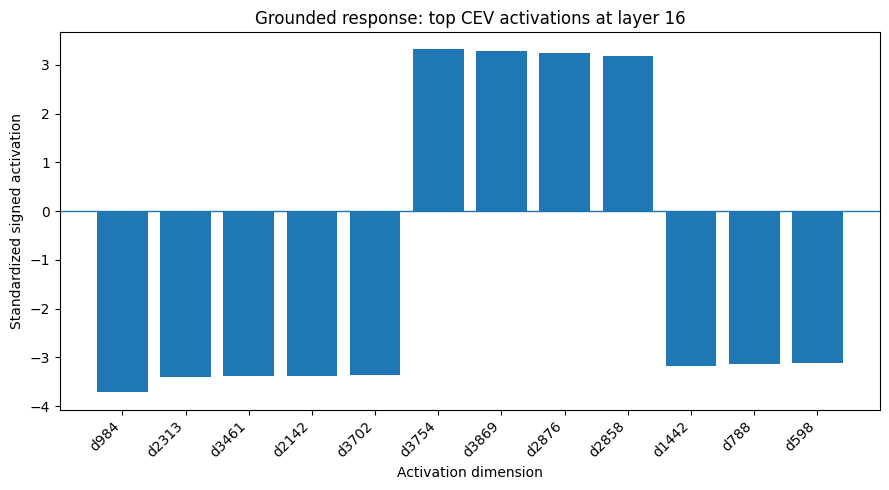

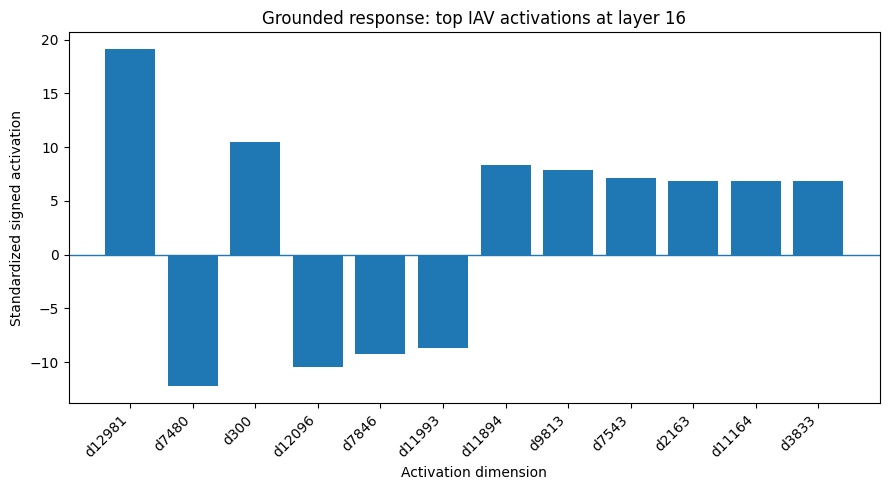

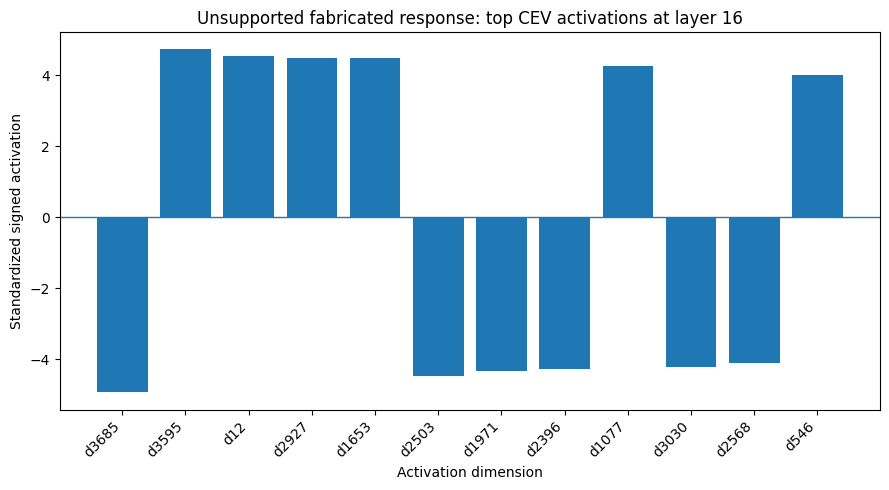

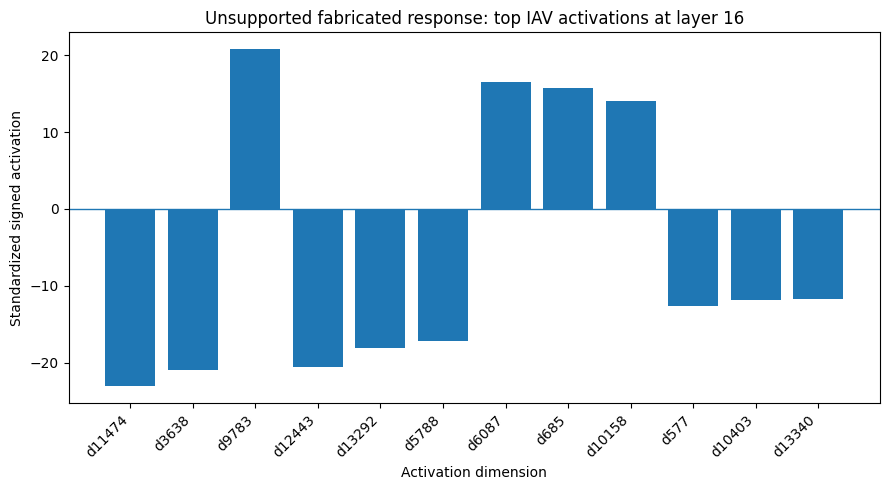

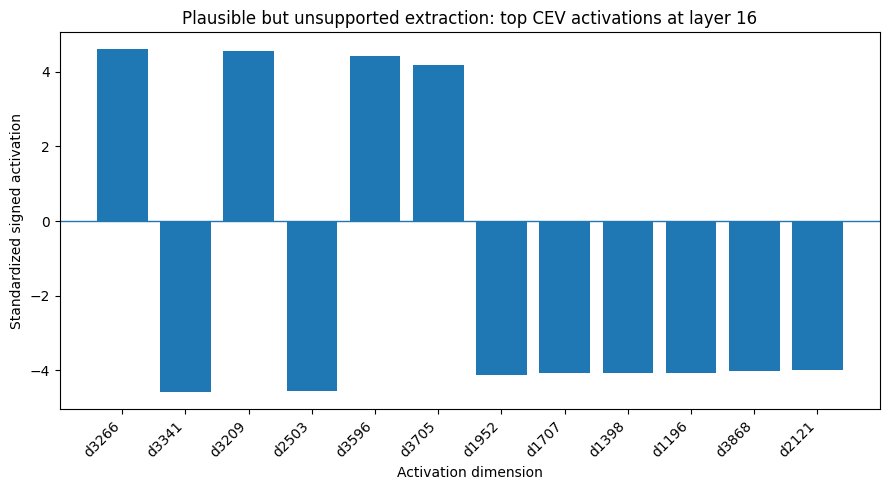

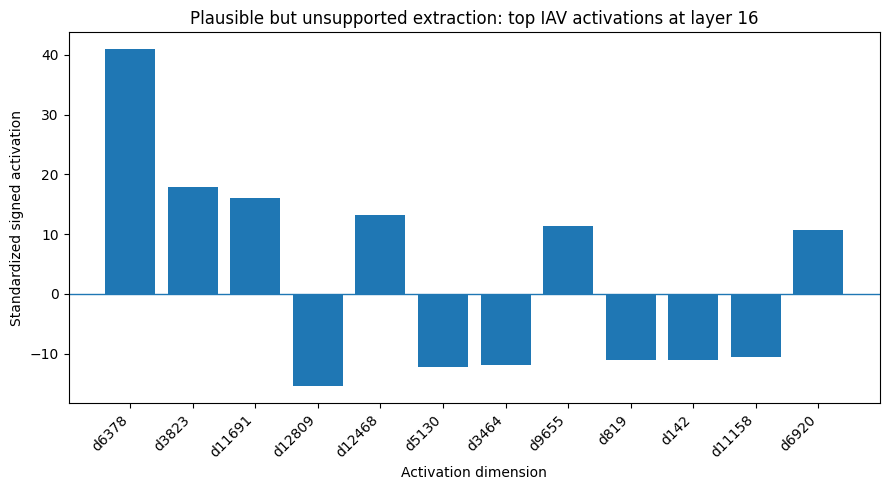


Exact illustrative-example summary
            example_id  expected_label  layer  cev_dimension  iav_dimension  cev_probability  iav_probability  fused_probability  query_context_similarity controller_action
   grounded_westphalia               0     16           4096          14336         0.124162         0.158108           0.153016                  0.860543            ACCEPT
 hallucinated_atlantis               1     16           4096          14336         0.705688         0.784560           0.772729                  0.568601        REGENERATE
false_accept_breakfast               1     16           4096          14336         0.362795         0.441553           0.429739                  0.697800            ACCEPT

Saved summary: /kaggle/working/illustrative_cev_iav_examples/illustrative_cev_iav_summary.csv


In [9]:
# -------------------------------------------------------------------------
# Controlled examples for exact activation inspection.
# These candidate responses are fixed so the extracted vectors are reproducible
# for a given model/probe checkpoint.
# -------------------------------------------------------------------------
illustrative_examples = [
    {
        "example_id": "grounded_westphalia",
        "category": "Grounded response",
        "query": "What year did the Treaty of Westphalia end the Thirty Years' War?",
        "context": (
            "The Peace of Westphalia was signed in 1648 and ended "
            "the Thirty Years' War."
        ),
        "candidate_response": (
            "The Treaty of Westphalia ended the Thirty Years' War in 1648."
        ),
        "expected_label": 0,
    },
    {
        "example_id": "hallucinated_atlantis",
        "category": "Unsupported fabricated response",
        "query": (
            "What is the official 2024 census population of the lost city "
            "of Atlantis?"
        ),
        "context": (
            "A 2024 census of South Atlantic territories found populations "
            "across several islands."
        ),
        "candidate_response": (
            "According to the 2024 census, Atlantis had a population of 140,634."
        ),
        "expected_label": 1,
    },
    {
        "example_id": "false_accept_breakfast",
        "category": "Plausible but unsupported extraction",
        "query": "What did I have for breakfast yesterday?",
        "context": (
            "Common breakfast foods include eggs, toast, coffee, and fruit."
        ),
        "candidate_response": (
            "Based on the context, you had eggs, toast, and coffee."
        ),
        "expected_label": 1,
    },
]


def vector_statistics(vector: torch.Tensor) -> Dict[str, float]:
    x = vector.detach().float().reshape(-1).cpu()
    return {
        "dimension": int(x.numel()),
        "mean": float(x.mean()),
        "std": float(x.std(unbiased=False)),
        "minimum": float(x.min()),
        "maximum": float(x.max()),
        "l2_norm": float(torch.linalg.vector_norm(x)),
    }


def top_signed_dimensions(
    vector: torch.Tensor,
    top_k: int,
) -> pd.DataFrame:
    x = vector.detach().float().reshape(-1).cpu()
    k = min(int(top_k), x.numel())
    indices = torch.topk(x.abs(), k=k).indices
    frame = pd.DataFrame(
        {
            "dimension_index": indices.numpy().astype(int),
            "signed_activation": x[indices].numpy(),
            "absolute_activation": x[indices].abs().numpy(),
        }
    )
    return frame.sort_values("absolute_activation", ascending=False).reset_index(drop=True)


def context_similarity(
    query: str,
    context: str,
    embedding_model: SentenceTransformer,
) -> float:
    embeddings = embedding_model.encode(
        [query, context],
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=False,
    )
    return float(np.dot(embeddings[0], embeddings[1]))


def controller_action(
    fused_score: float,
    similarity: float,
) -> str:
    if fused_score < config.hallucination_threshold:
        return "ACCEPT"
    if fused_score >= config.abstain_threshold:
        return "ABSTAIN"
    if similarity < config.retrieval_quality_threshold:
        return "RE-RETRIEVE"
    return "REGENERATE"


def plot_top_activations(
    top_frame: pd.DataFrame,
    title: str,
    output_path: str,
) -> None:
    labels = [f"d{index}" for index in top_frame["dimension_index"]]
    values = top_frame["signed_activation"].to_numpy()

    plt.figure(figsize=(9, 5))
    plt.bar(labels, values)
    plt.axhline(0.0, linewidth=1)
    plt.xlabel("Activation dimension")
    plt.ylabel("Standardized signed activation")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()


def save_complete_vector(
    raw_vector: torch.Tensor,
    standardized_vector: torch.Tensor,
    path: str,
) -> None:
    raw = raw_vector.detach().float().reshape(-1).cpu()
    standardized = standardized_vector.detach().float().reshape(-1).cpu()
    frame = pd.DataFrame(
        {
            "dimension_index": np.arange(raw.numel(), dtype=int),
            "raw_activation": raw.numpy(),
            "standardized_activation": standardized.numpy(),
            "absolute_standardized_activation": standardized.abs().numpy(),
        }
    )
    frame.to_csv(path, index=False)


# Load the embedding model on CPU only after probe training.
similarity_model = SentenceTransformer(config.embedding_model, device="cpu")

example_results: List[Dict[str, Any]] = []
example_vectors: Dict[str, Dict[str, torch.Tensor]] = {}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cev_probe.to(device).eval()
iav_probe.to(device).eval()

for example in illustrative_examples:
    example_id = example["example_id"]
    full_text = (
        format_rag_prompt(example["query"], example["context"])
        + " "
        + example["candidate_response"]
    )

    extraction = extractor.extract(full_text, return_attention=False)

    # Exact raw last-token activations from the selected single middle layer.
    raw_cev = extractor.get_pooled_cev_for_layer(
        extraction,
        mid_layer,
        "last",
    ).squeeze(0).float().cpu()

    raw_iav = extractor.get_pooled_iav_for_layer(
        extraction,
        mid_layer,
        "last",
    ).squeeze(0).float().cpu()

    standardized_cev, standardized_iav = standardize_probe_features(
        raw_cev.unsqueeze(0).to(device),
        raw_iav.unsqueeze(0).to(device),
    )
    standardized_cev = standardized_cev.squeeze(0).detach().cpu()
    standardized_iav = standardized_iav.squeeze(0).detach().cpu()

    with torch.no_grad():
        cev_score = float(
            cev_probe.predict_proba(
                standardized_cev.unsqueeze(0).to(device),
                config.probe_temp_cev,
            ).item()
        )
        iav_score = float(
            iav_probe.predict_proba(
                standardized_iav.unsqueeze(0).to(device),
                config.probe_temp_iav,
            ).item()
        )

    fused_score = fused_probability(cev_score, iav_score)
    similarity = context_similarity(
        example["query"],
        example["context"],
        similarity_model,
    )
    action = controller_action(fused_score, similarity)

    raw_cev_stats = vector_statistics(raw_cev)
    raw_iav_stats = vector_statistics(raw_iav)
    standardized_cev_stats = vector_statistics(standardized_cev)
    standardized_iav_stats = vector_statistics(standardized_iav)

    top_cev = top_signed_dimensions(
        standardized_cev,
        config.top_k_dimensions,
    )
    top_iav = top_signed_dimensions(
        standardized_iav,
        config.top_k_dimensions,
    )

    example_dir = os.path.join(config.output_dir, example_id)
    os.makedirs(example_dir, exist_ok=True)

    cev_csv = os.path.join(example_dir, f"{example_id}_cev_vector.csv")
    iav_csv = os.path.join(example_dir, f"{example_id}_iav_vector.csv")
    top_cev_csv = os.path.join(example_dir, f"{example_id}_cev_top_dimensions.csv")
    top_iav_csv = os.path.join(example_dir, f"{example_id}_iav_top_dimensions.csv")
    cev_plot = os.path.join(example_dir, f"{example_id}_cev_top_dimensions.png")
    iav_plot = os.path.join(example_dir, f"{example_id}_iav_top_dimensions.png")

    save_complete_vector(raw_cev, standardized_cev, cev_csv)
    save_complete_vector(raw_iav, standardized_iav, iav_csv)
    top_cev.to_csv(top_cev_csv, index=False)
    top_iav.to_csv(top_iav_csv, index=False)

    plot_top_activations(
        top_cev,
        f"{example['category']}: top CEV activations at layer {mid_layer}",
        cev_plot,
    )
    plot_top_activations(
        top_iav,
        f"{example['category']}: top IAV activations at layer {mid_layer}",
        iav_plot,
    )

    example_vectors[example_id] = {
        "raw_cev": raw_cev,
        "raw_iav": raw_iav,
        "standardized_cev": standardized_cev,
        "standardized_iav": standardized_iav,
    }

    example_results.append(
        {
            "example_id": example_id,
            "category": example["category"],
            "expected_label": example["expected_label"],
            "layer": mid_layer,
            "cev_dimension": raw_cev_stats["dimension"],
            "iav_dimension": raw_iav_stats["dimension"],
            "cev_raw_mean": raw_cev_stats["mean"],
            "cev_raw_std": raw_cev_stats["std"],
            "cev_raw_min": raw_cev_stats["minimum"],
            "cev_raw_max": raw_cev_stats["maximum"],
            "cev_raw_l2": raw_cev_stats["l2_norm"],
            "iav_raw_mean": raw_iav_stats["mean"],
            "iav_raw_std": raw_iav_stats["std"],
            "iav_raw_min": raw_iav_stats["minimum"],
            "iav_raw_max": raw_iav_stats["maximum"],
            "iav_raw_l2": raw_iav_stats["l2_norm"],
            "cev_z_mean": standardized_cev_stats["mean"],
            "cev_z_std": standardized_cev_stats["std"],
            "cev_z_min": standardized_cev_stats["minimum"],
            "cev_z_max": standardized_cev_stats["maximum"],
            "cev_z_l2": standardized_cev_stats["l2_norm"],
            "iav_z_mean": standardized_iav_stats["mean"],
            "iav_z_std": standardized_iav_stats["std"],
            "iav_z_min": standardized_iav_stats["minimum"],
            "iav_z_max": standardized_iav_stats["maximum"],
            "iav_z_l2": standardized_iav_stats["l2_norm"],
            "cev_probability": cev_score,
            "iav_probability": iav_score,
            "fused_probability": fused_score,
            "query_context_similarity": similarity,
            "controller_action": action,
            "query": example["query"],
            "context": example["context"],
            "candidate_response": example["candidate_response"],
            "cev_vector_csv": cev_csv,
            "iav_vector_csv": iav_csv,
            "cev_plot": cev_plot,
            "iav_plot": iav_plot,
        }
    )

    del extraction
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


example_results_df = pd.DataFrame(example_results)
summary_path = os.path.join(config.output_dir, "illustrative_cev_iav_summary.csv")
example_results_df.to_csv(summary_path, index=False)

display_columns = [
    "example_id",
    "expected_label",
    "layer",
    "cev_dimension",
    "iav_dimension",
    "cev_probability",
    "iav_probability",
    "fused_probability",
    "query_context_similarity",
    "controller_action",
]
print("\nExact illustrative-example summary")
print(example_results_df[display_columns].to_string(index=False))
print(f"\nSaved summary: {summary_path}")


---
## 10. Compare Complete Activation Patterns

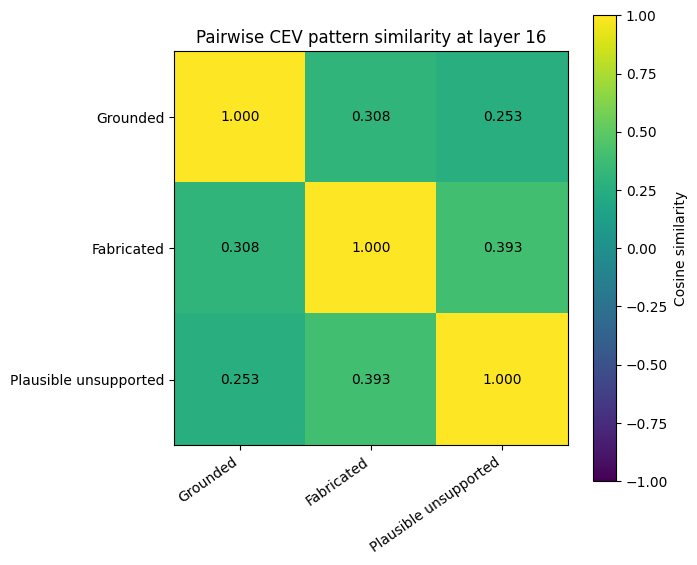

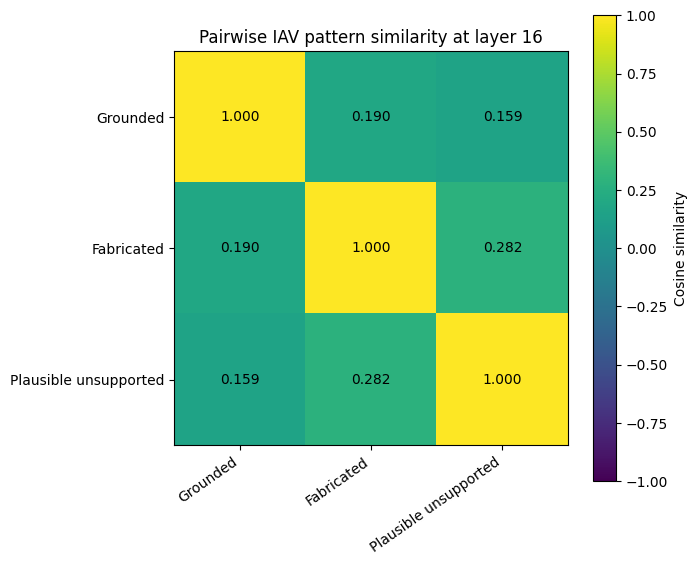

LaTeX-ready values saved to: /kaggle/working/illustrative_cev_iav_examples/illustrative_cev_iav_latex_values.txt
CEV similarity figure: /kaggle/working/illustrative_cev_iav_examples/pairwise_cev_cosine_similarity.png
IAV similarity figure: /kaggle/working/illustrative_cev_iav_examples/pairwise_iav_cosine_similarity.png


In [10]:
def cosine_similarity_matrix(vectors: List[torch.Tensor]) -> np.ndarray:
    stacked = torch.stack([vector.float().reshape(-1) for vector in vectors])
    stacked = F.normalize(stacked, p=2, dim=1)
    return (stacked @ stacked.T).cpu().numpy()


def plot_similarity_matrix(
    matrix: np.ndarray,
    labels: List[str],
    title: str,
    output_path: str,
) -> None:
    plt.figure(figsize=(7, 6))
    image = plt.imshow(matrix, vmin=-1.0, vmax=1.0)
    plt.colorbar(image, label="Cosine similarity")
    plt.xticks(range(len(labels)), labels, rotation=35, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.title(title)

    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            plt.text(
                column,
                row,
                f"{matrix[row, column]:.3f}",
                ha="center",
                va="center",
            )

    plt.tight_layout()
    plt.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()


example_ids = [example["example_id"] for example in illustrative_examples]
short_labels = ["Grounded", "Fabricated", "Plausible unsupported"]

cev_similarity = cosine_similarity_matrix(
    [example_vectors[example_id]["standardized_cev"] for example_id in example_ids]
)
iav_similarity = cosine_similarity_matrix(
    [example_vectors[example_id]["standardized_iav"] for example_id in example_ids]
)

cev_similarity_path = os.path.join(
    config.output_dir,
    "pairwise_cev_cosine_similarity.png",
)
iav_similarity_path = os.path.join(
    config.output_dir,
    "pairwise_iav_cosine_similarity.png",
)

plot_similarity_matrix(
    cev_similarity,
    short_labels,
    f"Pairwise CEV pattern similarity at layer {mid_layer}",
    cev_similarity_path,
)
plot_similarity_matrix(
    iav_similarity,
    short_labels,
    f"Pairwise IAV pattern similarity at layer {mid_layer}",
    iav_similarity_path,
)

pd.DataFrame(
    cev_similarity,
    index=short_labels,
    columns=short_labels,
).to_csv(os.path.join(config.output_dir, "pairwise_cev_cosine_similarity.csv"))

pd.DataFrame(
    iav_similarity,
    index=short_labels,
    columns=short_labels,
).to_csv(os.path.join(config.output_dir, "pairwise_iav_cosine_similarity.csv"))


def latex_vector_fragment(
    top_frame: pd.DataFrame,
    symbol: str,
    layer: int,
    max_items: int = 8,
) -> str:
    rows = top_frame.head(max_items)
    entries = ", ".join(
        f"d_{{{int(row.dimension_index)}}}={float(row.signed_activation):+.4f}"
        for row in rows.itertuples()
    )
    return (
        f"$\\operatorname{{TopAbs}}"
        f"(\\mathbf{{z}}^{{({layer})}}_{{\\mathrm{{{symbol}}}}})"
        f"=\\{{{entries}\\}}$"
    )


latex_lines = [
    "% Auto-generated from exact single-mid-layer activation outputs.",
    "% Dimension indices are descriptive only and are not assigned semantic neuron labels.",
    "",
]

for example in illustrative_examples:
    example_id = example["example_id"]
    row = example_results_df.loc[
        example_results_df["example_id"] == example_id
    ].iloc[0]

    top_cev = pd.read_csv(
        os.path.join(
            config.output_dir,
            example_id,
            f"{example_id}_cev_top_dimensions.csv",
        )
    )
    top_iav = pd.read_csv(
        os.path.join(
            config.output_dir,
            example_id,
            f"{example_id}_iav_top_dimensions.csv",
        )
    )

    latex_lines.extend(
        [
            f"% {example['category']}",
            latex_vector_fragment(top_cev, "CEV", mid_layer),
            "",
            latex_vector_fragment(top_iav, "IAV", mid_layer),
            "",
            (
                f"$p_{{\\mathrm{{CEV}}}}={row['cev_probability']:.4f},\\;"
                f"p_{{\\mathrm{{IAV}}}}={row['iav_probability']:.4f},\\;"
                f"p_{{\\mathrm{{fused}}}}={row['fused_probability']:.4f}$"
            ),
            "",
            f"Observed controller action: {row['controller_action']}.",
            "",
        ]
    )

latex_output_path = os.path.join(
    config.output_dir,
    "illustrative_cev_iav_latex_values.txt",
)
with open(latex_output_path, "w", encoding="utf-8") as handle:
    handle.write("\n".join(latex_lines))

print(f"LaTeX-ready values saved to: {latex_output_path}")
print(f"CEV similarity figure: {cev_similarity_path}")
print(f"IAV similarity figure: {iav_similarity_path}")



# Final Summary
This notebook is limited to **Illustrative CEV/IAV Examples.**

***Interpretation rule***

Large activation values are reported only by dimension index and signed magnitude. The notebook does not claim that a dimension is a date neuron,''food neuron,'' or ``confabulation neuron.'' Such semantic labels would require a separate causal or neuron-level interpretability analysis.

---
## 11. Final Verification

In [11]:
# Final verification check for the focused notebook.
EXPECTED_HF_MODEL = "mistralai/Mistral-7B-Instruct-v0.2"

assert config.model_name == EXPECTED_HF_MODEL, (
    f"Unexpected model ID: {config.model_name}"
)
assert not config.model_name.startswith("/kaggle/input"), (
    "A hardcoded Kaggle model path is still present."
)
assert len(model.model.layers) == 32
assert config.target_layers == [16]
assert config.hidden_size == 4096
assert config.intermediate_size == 14336

assert extractor.capture_last_token_only
assert config.max_context_length == 2048

required_summary_columns = {
    "example_id",
    "layer",
    "cev_dimension",
    "iav_dimension",
    "cev_probability",
    "iav_probability",
    "fused_probability",
    "controller_action",
}

assert config.probe_train_samples == 1500, "The reduced Kaggle sample cap changed."
assert config.probe_concat_n_layers == 1, "Probe configuration is not single-layer."
assert config.target_layers == [len(model.model.layers) // 2]
assert mid_layer == len(model.model.layers) // 2
assert required_summary_columns.issubset(example_results_df.columns)
assert len(example_results_df) == 3

for example_id, vectors in example_vectors.items():
    raw_cev = vectors["raw_cev"]
    raw_iav = vectors["raw_iav"]
    standardized_cev = vectors["standardized_cev"]
    standardized_iav = vectors["standardized_iav"]

    assert raw_cev.numel() == config.hidden_size
    assert raw_iav.numel() == config.intermediate_size
    assert standardized_cev.numel() == config.hidden_size
    assert standardized_iav.numel() == config.intermediate_size
    assert torch.isfinite(raw_cev).all()
    assert torch.isfinite(raw_iav).all()
    assert torch.isfinite(standardized_cev).all()
    assert torch.isfinite(standardized_iav).all()

for path_column in ("cev_vector_csv", "iav_vector_csv", "cev_plot", "iav_plot"):
    for output_path in example_results_df[path_column]:
        assert os.path.isfile(output_path), f"Missing output: {output_path}"

assert os.path.isfile(
    os.path.join(config.checkpoint_dir, "single_mid_layer_probe_bundle.pt")
)
assert os.path.isfile(
    os.path.join(config.output_dir, "illustrative_cev_iav_summary.csv")
)
assert os.path.isfile(
    os.path.join(config.output_dir, "illustrative_cev_iav_latex_values.txt")
)
assert os.path.isfile(
    os.path.join(config.output_dir, "pairwise_cev_cosine_similarity.png")
)
assert os.path.isfile(
    os.path.join(config.output_dir, "pairwise_iav_cosine_similarity.png")
)

print("=" * 72)
print("FINAL VERIFICATION: PASSED")
print("=" * 72)
print(f"Model layers: {len(model.model.layers)}")
print(f"Selected single middle layer: {mid_layer}")
print(f"CEV dimension: {config.hidden_size}")
print(f"IAV dimension: {config.intermediate_size}")
print(f"RAGTruth cap retained: {config.probe_train_samples}")
print("Hook storage: last token only")
print(f"Maximum token length retained: {config.max_context_length}")
print(f"Examples extracted: {len(example_results_df)}")
print(f"Fused validation AUROC: {config.probe_fused_val_auroc:.4f}")
print(f"All outputs: {config.output_dir}")


FINAL VERIFICATION: PASSED
Model layers: 32
Selected single middle layer: 16
CEV dimension: 4096
IAV dimension: 14336
RAGTruth cap retained: 1500
Hook storage: last token only
Maximum token length retained: 2048
Examples extracted: 3
Fused validation AUROC: 0.8307
All outputs: /kaggle/working/illustrative_cev_iav_examples
